# Pytorch Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

In [2]:
start_time = time.time()

In [3]:
torch.__version__

'2.9.0+cpu'

## Create Toy Data Set

In [4]:
X = torch.linspace(1, 50, 50).reshape(-1,1)

In [5]:
# X

In [6]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1),dtype=torch.float)

In [7]:
# e

In [8]:
y = 2*X + 1 + e

In [9]:
y.shape

torch.Size([50, 1])

Text(0.5, 1.0, 'Linear Dataset Scatter Plot')

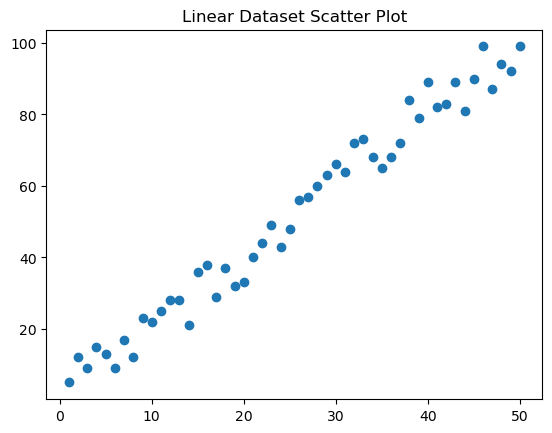

In [10]:
plt.scatter(X.numpy(), y.numpy()) ;
plt.title("Linear Dataset Scatter Plot")

## Sample Linear Calculation

In [11]:
torch.manual_seed(59)

model = torch.nn.Linear(in_features=1, out_features=1)

print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


## Create Pytorch Model Class

In [12]:
class Model(nn.Module):

    def __init__(self,in_features,out_features):
        super().__init__()
        self.linear = nn.Linear(1,1)

    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

In [13]:
torch.manual_seed(59)

model = Model(1,1)

print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [14]:
for name, param in model.named_parameters():
    print(name,"\t", param.item())

linear.weight 	 0.10597813129425049
linear.bias 	 0.9637961387634277


In [15]:
x = torch.tensor([[2.0]])
# x = x.unsqueeze(0) 
print(model.forward(x))

tensor([[1.1758]], grad_fn=<AddmmBackward0>)


### Model Training

In [16]:
x1 = np.linspace(0.0, 50.0, 50)

In [17]:
x1

array([ 0.        ,  1.02040816,  2.04081633,  3.06122449,  4.08163265,
        5.10204082,  6.12244898,  7.14285714,  8.16326531,  9.18367347,
       10.20408163, 11.2244898 , 12.24489796, 13.26530612, 14.28571429,
       15.30612245, 16.32653061, 17.34693878, 18.36734694, 19.3877551 ,
       20.40816327, 21.42857143, 22.44897959, 23.46938776, 24.48979592,
       25.51020408, 26.53061224, 27.55102041, 28.57142857, 29.59183673,
       30.6122449 , 31.63265306, 32.65306122, 33.67346939, 34.69387755,
       35.71428571, 36.73469388, 37.75510204, 38.7755102 , 39.79591837,
       40.81632653, 41.83673469, 42.85714286, 43.87755102, 44.89795918,
       45.91836735, 46.93877551, 47.95918367, 48.97959184, 50.        ])

In [18]:
w1 = 0.10597813129425049
b1 = 0.9637961387634277

y1 = w1*x1+b1

In [19]:
y1

array([0.96379614, 1.07193709, 1.18007804, 1.28821899, 1.39635994,
       1.50450089, 1.61264184, 1.72078279, 1.82892374, 1.93706469,
       2.04520564, 2.15334659, 2.26148754, 2.36962849, 2.47776944,
       2.58591039, 2.69405134, 2.80219229, 2.91033324, 3.01847419,
       3.12661514, 3.2347561 , 3.34289705, 3.451038  , 3.55917895,
       3.6673199 , 3.77546085, 3.8836018 , 3.99174275, 4.0998837 ,
       4.20802465, 4.3161656 , 4.42430655, 4.5324475 , 4.64058845,
       4.7487294 , 4.85687035, 4.9650113 , 5.07315225, 5.1812932 ,
       5.28943415, 5.3975751 , 5.50571605, 5.613857  , 5.72199795,
       5.8301389 , 5.93827985, 6.0464208 , 6.15456175, 6.2627027 ])

#### Graph the results

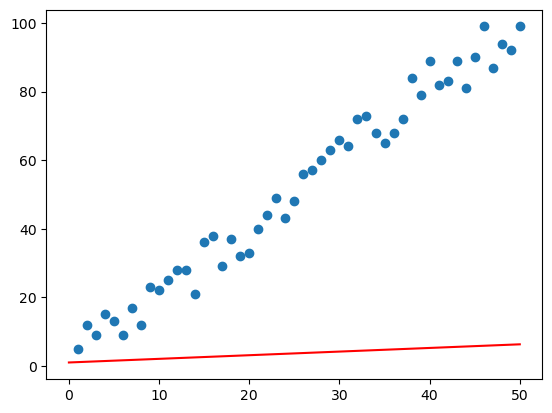

In [20]:
plt.scatter(X.numpy(), y.numpy())
plt.plot(x1,y1,"r") ;

#### Adding a loss function

In [21]:
criterion = nn.MSELoss() 

In [22]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

In [23]:
epochs = 50
losses = []

for i in range(epochs):
    i = i + 1
    # Predicting on forward pass
    y_pred = model.forward(X)
    # Calculate the loss on each pass
    loss = criterion(y_pred, y)
    # Record the loss
    losses.append(loss.item())
    # print eacbias result
    print(f"epoch {i} loss: {loss.item()} weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}")

    # Adjusting calculations
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()




epoch 1 loss: 3057.216796875 weight: 0.10597813129425049 bias: 0.9637961387634277
epoch 2 loss: 1588.5311279296875 weight: 3.334900379180908 bias: 1.0604636669158936
epoch 3 loss: 830.2999877929688 weight: 1.0148327350616455 bias: 0.9922628402709961
epoch 4 loss: 438.8524169921875 weight: 2.6817996501922607 bias: 1.0425218343734741
epoch 5 loss: 236.7615203857422 weight: 1.4840211868286133 bias: 1.0076650381088257
epoch 6 loss: 132.4291229248047 weight: 2.3446059226989746 bias: 1.0339646339416504
epoch 7 loss: 78.56572723388672 weight: 1.7262253761291504 bias: 1.0163217782974243
epoch 8 loss: 50.75775909423828 weight: 2.170504093170166 bias: 1.0302516222000122
epoch 9 loss: 36.4012565612793 weight: 1.851245641708374 bias: 1.0214954614639282
epoch 10 loss: 28.989229202270508 weight: 2.0806007385253906 bias: 1.029038906097412
epoch 11 loss: 25.162382125854492 weight: 1.9157683849334717 bias: 1.0248701572418213
epoch 12 loss: 23.186473846435547 weight: 2.034165620803833 bias: 1.0291162729

#### Chart the results

Text(0, 0.5, 'Loss')

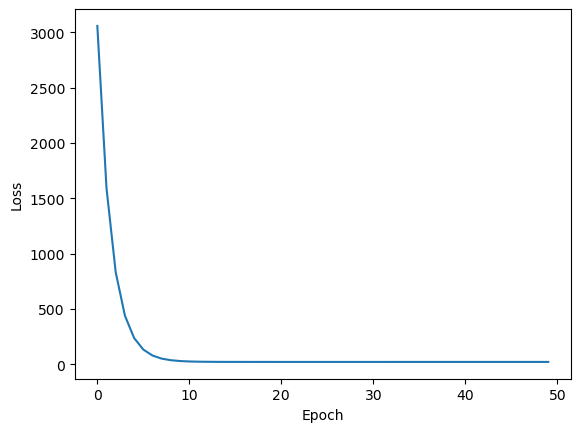

In [24]:
plt.plot(range(epochs),losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")


In [25]:
x = np.linspace(0.0, 50.0, 50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight*x + current_bias

In [26]:
predicted_y

array([  1.05575156,   3.08005679,   5.10436203,   7.12866726,
         9.15297249,  11.17727772,  13.20158295,  15.22588818,
        17.25019342,  19.27449865,  21.29880388,  23.32310911,
        25.34741434,  27.37171957,  29.39602481,  31.42033004,
        33.44463527,  35.4689405 ,  37.49324573,  39.51755096,
        41.5418562 ,  43.56616143,  45.59046666,  47.61477189,
        49.63907712,  51.66338236,  53.68768759,  55.71199282,
        57.73629805,  59.76060328,  61.78490851,  63.80921375,
        65.83351898,  67.85782421,  69.88212944,  71.90643467,
        73.9307399 ,  75.95504514,  77.97935037,  80.0036556 ,
        82.02796083,  84.05226606,  86.07657129,  88.10087653,
        90.12518176,  92.14948699,  94.17379222,  96.19809745,
        98.22240268, 100.24670792])

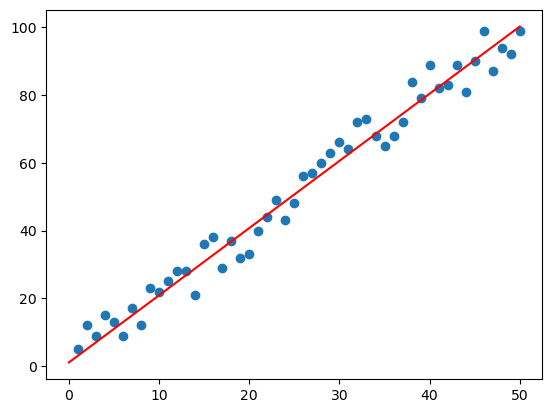

In [27]:
plt.scatter(X.numpy(), y.numpy())
plt.plot(x, predicted_y, "r")

In [28]:
end_time = time.time()
total_time = end_time - start_time
print(f"total run seconds: {total_time}")

total run seconds: 2.4087562561035156
